# Summary

# 1. Performing computations

In [1]:
%config InlineBackend.figure_format = "retina"

import glob
import importlib
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

project_root = os.path.abspath(".")
scripts_dir = os.path.join(project_root, "scripts", "analysis")
sys.path.insert(0, scripts_dir)

import display as _display_helpers
import utils
from utils import (
    CALLER_KEYS, CHROMHMM_DEFAULT, COSINE, FULL, FULL_DISPLAY,
    JACCARD, JACCARD_DISPLAY, JOINT_CHROMHMM, JOINT_HATCH, JOINT_KMEANS_HOMER,
    JOINT_KMEANS_MACS2, JOINT_KMEANS_OMNI, KAPPA, KMEANS_HOMER,
    KMEANS_MACS2, KMEANS_OMNI, NOQH, NOQH_DISPLAY, POINT_SIZE
)

for _m in (utils, _display_helpers):
    importlib.reload(_m)

from display import header, show_all

In [2]:
# Comparison parameters
COMPARISON_METRICS = [KAPPA]
COMPARISON_DOMAINS = [FULL]

# Cosine is read out of the same caches but never averaged into the agreement
# axes: it lands on the composition axes of its own, so the collectors ask for
# one metric column more than COMPARISON_METRICS names.
COLLECTED_METRICS = COMPARISON_METRICS + [COSINE]

# The cosine of two state-composition vectors saturates at 1 as soon as one
# state dominates both sides (see utils.COMPOSITION), which on the Full domain
# it always does: Quies alone takes 70-90% of the genome, so a Full cosine
# ranks the methods on the fourth decimal of their Quies budget and rewards
# whichever segmentation is least responsive to its input. The composition axes
# are therefore scored on NOQH alone, with Quies and Het dropped, where the
# cosine compares the states the callers actually disagree about.
COSINE_DOMAINS = [NOQH]

# Every domain a collector has to open a cache for, cosine's included.
COLLECTED_DOMAINS = list(dict.fromkeys(COMPARISON_DOMAINS + COSINE_DOMAINS))


def metric_domains(metric):
    """The comparison domains `metric` is collected and ranked in."""
    return (COSINE_DOMAINS if utils.normalize_metric(metric) == COSINE
            else COMPARISON_DOMAINS)

# The same, spelled out for the axis labels and the evidence notes.
# We average Jaccard and Kappa, but keep Cosine separate.
AVG_METRICS = [KAPPA]
AVG_METRIC_LABEL = " / ".join(utils.metric_display(m) for m in AVG_METRICS)
AVG_METRICS_LABEL = " and ".join(utils.metric_display(m) for m in AVG_METRICS)
DOMAINS_LABEL = " and ".join(utils.domain_display(d) for d in COMPARISON_DOMAINS)
COSINE_DOMAINS_LABEL = " and ".join(utils.domain_display(d) for d in COSINE_DOMAINS)
print(f"  metrics {COMPARISON_METRICS} over {COMPARISON_DOMAINS}, "
      f"[{COSINE!r}] over {COSINE_DOMAINS}")

OUT = "out/summary"
os.makedirs(OUT, exist_ok=True)

  metrics ['kappa'] over ['full'], ['cosine'] over ['noqh']


In [3]:
METHODS = [
    CHROMHMM_DEFAULT,
    KMEANS_HOMER,
    KMEANS_MACS2,
    KMEANS_OMNI,
    JOINT_CHROMHMM,
    JOINT_KMEANS_HOMER,
    JOINT_KMEANS_MACS2,
    JOINT_KMEANS_OMNI,
]

# The two model families are ranked separately: the individual models have
# evidence on every axis, the joint ones only on the ones that neither compare
# a sample against a joint model nor need the enrichment tables they have none
# of.
INDIVIDUAL_METHODS = [m for m in METHODS if not m.startswith("joint")]
JOINT_METHODS = [m for m in METHODS if m.startswith("joint")]


DATASETS = ["encode", "sagaconf", "epi1000"]

DATASET_NAMES = {"encode": "ENCODE", "sagaconf": "SAGAconf", "epi1000": "1000 epigenomes"}

AXES = {
    "replicates": (
        "Replicate\nagreement", "high", AVG_METRIC_LABEL,
        f"Agreement between segmentations of biological replicates of the same "
        f"condition, averaged over {AVG_METRICS_LABEL} and {DOMAINS_LABEL}."),
    "replicates_cosine": (
        "Replicate\ncomposition", "high", "Cosine",
        f"Agreement of state composition between biological replicates, "
        f"measured by Cosine similarity over {COSINE_DOMAINS_LABEL}."),
    "replicates_emissions": (
        "Replicate emission\nsimilarity", "high", "cosine of the state emissions",
        "Similarity of the state signatures a method learns from the two "
        "replicates of a sample: the mean cosine of the emission vectors of "
        "the matched states, over the one-to-one matching of the two state "
        "spaces. Higher means the same biology is described by the same state "
        "definitions."),
    "cross_sample": (
        "Cross-sample\nagreement", "high", AVG_METRIC_LABEL,
        f"Agreement between segmentations of different samples, averaged over "
        f"{AVG_METRICS_LABEL} and {DOMAINS_LABEL}."),
    "cross_sample_cosine": (
        "Cross-sample\ncomposition", "high", "Cosine",
        f"Agreement of state composition between different samples, "
        f"measured by Cosine similarity over {COSINE_DOMAINS_LABEL}."),
    "joint_indiv": (
        "Individual /\njoint agreement", "high", AVG_METRIC_LABEL,
        f"Agreement of a sample segmented on its own with the same sample "
        f"segmented inside a joint model, averaged over {AVG_METRICS_LABEL} and "
        f"{DOMAINS_LABEL}."),
    "joint_indiv_cosine": (
        "Individual / joint\ncomposition agreement", "high", "Cosine",
        f"Agreement of state composition between individual and joint "
        f"segmentations, measured by Cosine similarity over {COSINE_DOMAINS_LABEL}."),
    "entropy": (
        "Low transition\ncomplexity", "low", "transition matrix entropy",
        "Entropy of the state transition matrix: how fragmented the "
        "segmentation is. Lower means fewer spurious state switches. "
        f"Collected once per comparison domain, so {DOMAINS_LABEL} entropy are "
        "never ranked against each other."),
    "functional": (
        "Functional\ncorrespondence", "high", JACCARD_DISPLAY,
        "Overlap of the promoter and transcription states with independent "
        "RNA-seq and ATAC-seq experiments of the same sample, measured by Jaccard similarity."),
    "state_fidelity": (
        "State-space\nfidelity", "high", "fraction reaching k=15",
        "Fraction of segmentations that actually realize the 15 requested "
        "states instead of collapsing some of them."),
    "segments_stability": (
        "Segment-count\nstability", "low", "CV of segment number",
        "Coefficient of variation of the number of segments across the "
        "samples of a dataset — how much the granularity drifts with input."),
    "cross_assay_agreement": (
        "Cross-assay\nagreement", "high", AVG_METRIC_LABEL,
        f"Agreement between ChIP-seq and Mint-ChIP segmentations of the same "
        f"sample, averaged over {AVG_METRICS_LABEL} and {DOMAINS_LABEL}."),
    "cross_assay_agreement_cosine": (
        "Cross-assay\ncomposition agreement", "high", "Cosine",
        f"Agreement of state composition between ChIP-seq and Mint-ChIP "
        f"segmentations, measured by Cosine similarity over {COSINE_DOMAINS_LABEL}."),
    "cross_assay_segments_stability": (
        "Cross-assay\ncounts stability", "low", "CV of segment number",
        "Coefficient of variation of the number of segments across ChIP-seq "
        "and Mint-ChIP experiments of the same sample."),
}

AXIS_ORDER = [
    "state_fidelity", "segments_stability",
    "entropy",
    "functional",
    "cross_sample", "cross_sample_cosine",
    "replicates", "replicates_cosine",
    "replicates_emissions",
    "cross_assay_segments_stability", "cross_assay_agreement", "cross_assay_agreement_cosine",
    "joint_indiv", "joint_indiv_cosine",
]

# Axes collected once per comparison domain (and per metric, where they compare
# two segmentations) rather than once overall, so that no score mixes domains:
# every variant is ranked only against the same-domain evidence of the other
# methods, and axis_scores() averages the variants back into the main axis.
VARIANT_MAIN_AXES = ["replicates", "replicates_cosine",
                     "cross_sample", "cross_sample_cosine",
                     "joint_indiv", "joint_indiv_cosine",
                     "cross_assay_agreement", "cross_assay_agreement_cosine",
                     "entropy"]


def axis_variants(main):
    """The per-domain (and, for the agreement axes, per-metric) variants the
    main axis is built from."""
    if main == "entropy":
        return [f"entropy_{mode}" for mode in COMPARISON_DOMAINS]

    # Cosine is its own axis, not averaged into the base one.
    if main.endswith("_cosine"):
        base = main[:-len("_cosine")]
        return [f"{base}_{COSINE}_{mode}" for mode in COSINE_DOMAINS]

    # Agreement axes: only average Jaccard and Kappa.
    return [f"{main}_{m}_{mode}"
            for m in AVG_METRICS for mode in COMPARISON_DOMAINS]


# A variant that already names an existing axis is not registered a second
# time, otherwise the axis category list would carry duplicates.
VARIANT_AXES = []
for main in VARIANT_MAIN_AXES:
    for v in axis_variants(main):
        if v in AXES:
            continue
        AXES[v] = (v, AXES[main][1], AXES[main][2], "Variant for ranking")
        VARIANT_AXES.append(v)

ALL_AXIS_CATEGORIES = AXIS_ORDER + VARIANT_AXES

EVIDENCE_COLUMNS = ["Axis", "Dataset", "Cell", "Method", "Value", "N", "Note"]


def canonical(name):
    return utils.normalize_method(name)


def axis_label(axis, oneline=False):
    label = AXES[str(axis)][0]
    return label.replace("\n", " ") if oneline else label


WORKDIRS = {}
for dataset, config_file in [("encode", "config_encode.yaml"),
                             ("sagaconf", "config_sagaconf.yaml")]:
    with open(os.path.join(project_root, config_file)) as f:
        WORKDIRS[dataset] = yaml.safe_load(f)["workdir"]
WORKDIRS["epi1000"] = os.path.join(os.path.dirname(WORKDIRS["encode"]), "epi1000")

for dataset, workdir in WORKDIRS.items():
    present = os.path.isdir(os.path.join(os.path.expanduser(workdir), "out"))
    print(f"  {DATASET_NAMES[dataset]:16s} {workdir}"
          f"{'' if present else '   (no out/ — run its notebook first)'}")

  ENCODE           ~/data/2026_segmentations/encode
  SAGAconf         ~/data/2026_segmentations/sagaconf
  1000 epigenomes  ~/data/2026_segmentations/epi1000


In [4]:
pd.DataFrame([{"Axis": axis_label(a, oneline=True), "Metric": AXES[a][2],
               "Better": AXES[a][1], "What it measures": AXES[a][3]}
              for a in AXIS_ORDER])

,Axis,Metric,Better,What it measures
0,State-space fidelity,fraction reaching k=15,high,Fraction of segmentations that actually realiz...
1,Segment-count stability,CV of segment number,low,Coefficient of variation of the number of segm...
2,Low transition complexity,transition matrix entropy,low,Entropy of the state transition matrix: how fr...
3,Functional correspondence,Jaccard,high,Overlap of the promoter and transcription stat...
4,Cross-sample agreement,Kappa,high,Agreement between segmentations of different s...
5,Cross-sample composition,Cosine,high,Agreement of state composition between differe...
6,Replicate agreement,Kappa,high,Agreement between segmentations of biological ...
7,Replicate composition,Cosine,high,Agreement of state composition between biologi...
8,Replicate emission similarity,cosine of the state emissions,high,Similarity of the state signatures a method le...
9,Cross-assay counts stability,CV of segment number,low,Coefficient of variation of the number of segm...


## Reading the caches into one evidence table

In [5]:
def _rows(axis, dataset, values, note, cell=None, n=None):
    return [{"Axis": axis, "Dataset": dataset, "Cell": cell or dataset,
             "Method": method, "Value": float(value), "Note": note,
             "N": (n or {}).get(method, np.nan)}
            for method, value in values.items()
            if method in METHODS and value is not None and not pd.isna(value)]


def _aggregate(df, method_col, value_col, mapper=canonical):
    keys = df[method_col].map(mapper)
    keep = keys.notna() & df[value_col].notna()
    grouped = df.loc[keep].groupby(keys[keep])[value_col]
    return grouped.mean().to_dict(), grouped.size().to_dict()


def _wanted_domain(mode):
    return utils.normalize_domain(mode) in COMPARISON_DOMAINS


def _no_cache(where, what):
    print(f"  {where}: no {what}, that variant is omitted")


def _find_column(df, *candidates):
    """The first of `candidates` present among the columns of `df`, matched
    case-insensitively; None when the cache carries none of them."""
    lookup = {str(c).lower(): c for c in df.columns}
    for candidate in candidates:
        if candidate is not None and str(candidate).lower() in lookup:
            return lookup[str(candidate).lower()]
    return None


def _domain_rows(df, mode, where):
    """The rows of a long cache belonging to comparison domain `mode`. ENCODE
    and SAGAconf spell the Mode column 'Full'/'NOQH' while the 1000-epigenomes
    caches spell it 'FULL'/'NOQH', so utils.normalize_domain() does the match."""
    col = _find_column(df, "Mode")
    if col is None:
        _no_cache(where, "Mode column")
        return None
    modes = df[col].astype(str)
    rows = df[modes.map(utils.normalize_domain) == utils.normalize_domain(mode)]
    if rows.empty:
        _no_cache(where, f"{mode} rows (the cache has "
                         f"{sorted(modes.unique())})")
        return None
    return rows


def _metric_column(df, metric, where, mode=None):
    """The column holding `metric`, matched case-insensitively. Pass `mode` for
    a wide cache that keeps one column per domain (kappa / kappa_noqh); leave it
    out when the domain lives in a Mode column instead.

    A metric can be spelled more than one way on disk, so every alias
    utils.metric_aliases() knows of is tried, canonical spelling first."""
    spellings = utils.metric_aliases(metric)
    if mode is None or utils.normalize_domain(mode) == FULL:
        candidates = list(spellings)
    else:
        candidates = [f"{spelling}_{mode}" for spelling in spellings]
    col = _find_column(df, *candidates)
    if col is None:
        _no_cache(where, f"a {metric} column (looked for {candidates})")
    return col


def _expand_callers(values, counts):
    out, out_n = {}, {}
    for method, value in values.items():
        for key in CALLER_KEYS.get(utils.caller_key(method), ()):
            out[key] = value
            out_n[key] = counts.get(method, np.nan)
    return out, out_n


def _cv(values):
    values = np.asarray([v for v in values if v is not None and not pd.isna(v)],
                        dtype=float)
    if len(values) < 2 or values.mean() == 0:
        return np.nan
    return float(values.std(ddof=1) / values.mean())


def _segments_stability(dataset, df, method_col, segments_col, cell=None):
    keys = df[method_col].map(canonical)
    keep = keys.notna()
    grouped = df.loc[keep].groupby(keys[keep])[segments_col]
    values = {method: _cv(group.values) for method, group in grouped}
    return _rows("segments_stability", dataset, values, cell=cell,
                 note=f"CV of the segment number over {int(keep.sum())} "
                      f"segmentations", n=grouped.size().to_dict())


def _replicate_emissions(out, datasets):
    """rep1-vs-rep2 emission similarity of every method, one row per dataset.

    Read from the per-dataset all-pairs comparison tables, since no notebook
    aggregates the emission cosine into a cache of its own. A joint model is
    only compared in the joint/ table, so both tables are read and a method
    reached by either one is kept once.
    """
    frames = []
    for ds in datasets:
        for rel in ("matched/comparison_all_pairs.tsv",
                    "matched/joint/comparison_all_pairs.tsv"):
            path = f"{out}/{ds}/{rel}"
            if not os.path.exists(path):
                continue
            df = _read(path)
            if df is None or utils.EMISSION not in df.columns:
                continue
            seg1, seg2 = df["seg1"].astype(str), df["seg2"].astype(str)
            pairs = [utils.is_replicate(a) and utils.should_compare(a, b)
                     for a, b in zip(seg1, seg2)]
            rows = df[pairs].dropna(subset=[utils.EMISSION])
            if rows.empty:
                continue
            frames.append(pd.DataFrame({
                "Dataset": ds,
                # Both replicate suffixes are five characters, so the method is
                # the label of either side with its suffix dropped.
                "Method": rows["seg1"].astype(str).str[:-len("_rep1")],
                utils.EMISSION: rows[utils.EMISSION].astype(float),
            }))
    if not frames:
        return None
    return (pd.concat(frames, ignore_index=True)
            .drop_duplicates(subset=["Dataset", "Method"]))


def _emission_rows(dataset, out, datasets, excluded, where):
    """The emission similarity evidence of one dataset, empty when uncached."""
    emissions = _drop_excluded(_replicate_emissions(out, datasets), excluded)
    if emissions is None or emissions.empty:
        _no_cache(where, f"{utils.EMISSION} in the all-pairs comparison "
                         f"tables")
        return []
    values, counts = _aggregate(emissions, "Method", utils.EMISSION)
    return _rows("replicates_emissions", dataset, values,
                 f"rep1 vs rep2 cosine of the matched state emission vectors, "
                 f"over {len(emissions)} segmentation pairs", n=counts)


def _read(path, **kwargs):
    if not os.path.exists(path):
        print(f"  missing {path}")
        return None
    if path.endswith(".pkl"):
        return pd.read_pickle(path)
    sep = "\t" if path.endswith(".tsv") else ","
    return pd.read_csv(path, sep=sep, **kwargs)


In [6]:
ENCODE_DATASETS = ["imr90", "monocytes", "monocytes_mint", "gm12878_mint", "spleen"]
SAGACONF_DATASETS = ["mcf7", "gm12878", "k562", "cd14_monocyte", "hela_s3"]

PROMOTER_STATES = ["Tss", "TssFlnk", "TssFlnkU", "TssFlnkD"]
TX_STATES = ["Tx", "TxWk"]
ENHANCER_STATES = ["Enh", "Enh1", "Enh2", "EnhG", "EnhG1", "EnhG2", "EnhLo"]

FUNCTIONAL_TARGETS = [
    ("Promoter states vs RefSeq TSS", PROMOTER_STATES, "RefSeqTSS2kb"),
    ("Promoter states vs expressed TSS", PROMOTER_STATES, "ExpressedTSS2kb"),
    ("Transcription states vs RefSeq genes", TX_STATES, "RefSeqGene"),
    ("Transcription states vs expressed genes", TX_STATES, "ExpressedGeneBodies"),
    ("Active states vs ATAC-seq", PROMOTER_STATES + ENHANCER_STATES, "atac_"),
]


def _scope(segmentation):
    return "replicates" if str(segmentation).endswith(("_rep1", "_rep2")) else "pooled"


def _encode_frames(out, filename, columns, datasets=ENCODE_DATASETS, label="encode"):
    frames = []
    for ds in datasets:
        for rel in (f"matched/{filename}", f"matched/joint/{filename}"):
            df = _read(f"{out}/{ds}/{rel}")
            if df is None:
                continue
            df = df.copy()
            df["Method"] = (df["segmentation"].astype(str)
                            .str.replace(r"_rep\d$", "", regex=True))
            df["Dataset"] = ds
            df["Cell"] = f"{label}:" + df["segmentation"].map(_scope)
            df["Segmentation"] = ds + ":" + df["segmentation"].astype(str)
            frames.append(df[["Dataset", "Segmentation", "Method", "Cell"] + columns])
    if not frames:
        return None
    return (pd.concat(frames, ignore_index=True)
            .drop_duplicates(subset=["Segmentation"]))


def incomplete_segmentations(workdir, datasets=ENCODE_DATASETS, label="encode",
                             min_share=0.5):
    out = os.path.join(os.path.expanduser(workdir), "out")
    stats = _encode_frames(out, "segment_stats.tsv", ["n_segments", "mean_length"],
                          datasets=datasets, label=label)
    if stats is None:
        return pd.DataFrame(columns=["Dataset", "Segmentation", "Method",
                                     "Covered_bp", "Share"])
    stats = stats.assign(Covered_bp=stats["n_segments"] * stats["mean_length"])
    median = stats.groupby("Dataset")["Covered_bp"].transform("median")
    stats["Share"] = stats["Covered_bp"] / median
    bad = stats[stats["Share"] < min_share].copy()
    bad["Method"] = bad["Method"].map(canonical)
    return bad[["Dataset", "Segmentation", "Method", "Covered_bp", "Share"]]


def _excluded_pairs(incomplete):
    pairs = {(ds, method)
             for ds, method in zip(incomplete["Dataset"], incomplete["Method"])
             if method is not None}
    if pairs:
        print("  excluding incomplete segmentations: "
              + ", ".join(f"{ds}/{m}" for ds, m in sorted(pairs)))
    return pairs


def _excluded_comparisons(pairs):
    return {(ds, key) for ds, method in pairs
            for key in CALLER_KEYS.get(utils.caller_key(method), (method,))}


def _drop_excluded(df, excluded):
    if not excluded or df is None or df.empty:
        return df
    datasets = df["Dataset"].astype(str).str.split("/").str[0]
    methods = df["Method"].map(canonical)
    keep = [(ds, m) not in excluded for ds, m in zip(datasets, methods)]
    return df[keep]


def _union_enrichment(dirpath, states, prefix):
    enrich = _read(f"{dirpath}/enrichment/enrichment.tsv")
    report = _read(f"{dirpath}/report.tsv")
    if enrich is None or report is None:
        return []
    sizes = report.set_index("state")["total_bp"]
    genome = sizes.sum()
    rows = []
    for label, group in enrich.groupby("label"):
        if not str(label).startswith(prefix):
            continue
        positive = group[group["fold_enrichment"] > 0]
        if positive.empty:
            continue
        annotation = float(np.median(positive["coverage"]
                                     / positive["fold_enrichment"])) * genome
        family = group[group["state"].isin(states)]
        family_bp = float(sizes.reindex(family["state"]).sum())
        if annotation <= 0 or family_bp <= 0:
            continue
        overlap = float((family["coverage"].values
                         * sizes.reindex(family["state"]).values).sum())
        rows.append({"Label": label,
                     JACCARD: overlap / (family_bp + annotation - overlap)})
    return rows


def _encode_functional(out):
    rows = []
    for path in sorted(glob.glob(f"{out}/*/matched/*/report.tsv")):
        dirpath = os.path.dirname(path)
        parts = dirpath.split(os.sep)
        ds, method = parts[-3], canonical(parts[-1])
        if method is None:
            continue
        for target, states, prefix in FUNCTIONAL_TARGETS:
            for row in _union_enrichment(dirpath, states, prefix):
                rows.append({"Dataset": ds, "Method": method, "Target": target,
                             "Cell": f"encode:{target}", **row})
    return pd.DataFrame(rows) if rows else None


def collect_encode(workdir):
    out = os.path.join(os.path.expanduser(workdir), "out")
    print(f"ENCODE caches in {out}")
    evidence = []
    incomplete = incomplete_segmentations(workdir)
    excluded = _excluded_pairs(incomplete)

    rep = _read(f"{out}/df_joint_rep.pkl")
    if rep is not None:
        rep = _drop_excluded(rep, excluded)
        for mode in COLLECTED_DOMAINS:
            rows = _domain_rows(rep, mode, "ENCODE df_joint_rep.pkl")
            if rows is None:
                continue
            for metric in COLLECTED_METRICS:
                if mode not in metric_domains(metric):
                    continue
                col = _metric_column(rows, metric, "ENCODE df_joint_rep.pkl")
                if col is None:
                    continue
                values, counts = _aggregate(rows, "Method", col)
                evidence += _rows(f"replicates_{metric}_{mode}",
                                  "encode", values,
                                  f"rep1 vs rep2 ({utils.metric_display(metric)}, {utils.domain_display(mode)})",
                                  n=counts)

    evidence += _emission_rows("encode", out, ENCODE_DATASETS, excluded,
                               "ENCODE")

    pairs = _read(f"{out}/comparison_table.tsv")
    if pairs is not None:
        for mode in COLLECTED_DOMAINS:
            for metric in COLLECTED_METRICS:
                if mode not in metric_domains(metric):
                    continue
                col = _metric_column(pairs, metric,
                                     "ENCODE comparison_table.tsv", mode)
                if col is None:
                    continue
                values, counts = _aggregate(pairs, "method", col)
                evidence += _rows(f"cross_sample_{metric}_{mode}",
                                  "encode", values,
                                  f"all pairs ({utils.metric_display(metric)}, {utils.domain_display(mode)})",
                                  n=counts)

    # Cross-assay (ChIP vs MINT) agreement
    chip_dss = [ds for ds in ENCODE_DATASETS if not ds.endswith("_mint")]
    mint_dss = [ds for ds in ENCODE_DATASETS if ds.endswith("_mint")]
    if pairs is not None and chip_dss and mint_dss:
        is_cross = (pairs["ds_a"].isin(chip_dss) & pairs["ds_b"].isin(mint_dss)) | \
                   (pairs["ds_a"].isin(mint_dss) & pairs["ds_b"].isin(chip_dss))
        cross_pairs = pairs[is_cross]
        for mode in COLLECTED_DOMAINS:
            for metric in COLLECTED_METRICS:
                if mode not in metric_domains(metric):
                    continue
                col = _metric_column(cross_pairs, metric,
                                     "ENCODE comparison_table.tsv", mode)
                if col is None:
                    continue
                values, counts = _aggregate(cross_pairs, "method", col)
                evidence += _rows(
                    f"cross_assay_agreement_{metric}_{mode}",
                    "encode", values,
                    f"ChIP vs MINT pairs ({utils.metric_display(metric)}, {utils.domain_display(mode)})", n=counts)

    joint = _read(f"{out}/df_joint_indiv.pkl")
    if joint is not None:
        joint = _drop_excluded(joint, _excluded_comparisons(excluded))
        for mode in COLLECTED_DOMAINS:
            rows = _domain_rows(joint, mode, "ENCODE df_joint_indiv.pkl")
            if rows is None:
                continue
            for metric in COLLECTED_METRICS:
                if mode not in metric_domains(metric):
                    continue
                col = _metric_column(rows, metric, "ENCODE df_joint_indiv.pkl")
                if col is None:
                    continue
                values, counts = _expand_callers(
                    *_aggregate(rows, "Method", col))
                evidence += _rows(f"joint_indiv_{metric}_{mode}",
                                  "encode", values,
                                  f"individual vs joint ({utils.metric_display(metric)}, "
                                  f"{utils.domain_display(mode)})", n=counts)

    for mode in COMPARISON_DOMAINS:
        suffix = "" if mode == FULL else f"_{mode}"
        entropy = _drop_excluded(
            _encode_frames(out, f"entropy_summary{suffix}.tsv", ["total_entropy"]),
            excluded)
        if entropy is None:
            _no_cache("ENCODE", f"entropy_summary{suffix}.tsv "
                                f"({utils.domain_display(mode)} transition matrix entropy)")
            continue
        for cell, group in entropy.groupby("Cell"):
            values, counts = _aggregate(group, "Method", "total_entropy")
            evidence += _rows(f"entropy_{mode}", "encode", values,
                              f"{utils.domain_display(mode)} transition matrix entropy of the "
                              f"{cell} segmentations", cell=cell, n=counts)

    functional = _encode_functional(out)
    if functional is not None:
        for cell, group in functional.groupby("Cell"):
            values, counts = _aggregate(group, "Method", JACCARD,
                                        mapper=lambda m: m)
            datasets = ", ".join(sorted(group["Dataset"].unique()))
            evidence += _rows("functional", "encode", values,
                              f"{JACCARD_DISPLAY} of the state family with the assay in "
                              f"{datasets}; the joint models have no enrichment "
                              f"tables", cell=cell, n=counts)

    segments = _drop_excluded(
        _encode_frames(out, "segment_stats.tsv", ["n_states", "n_segments"]), excluded)
    if segments is not None:
        segments = segments.assign(ok=segments["n_states"].eq(15).astype(float))
        for cell, group in segments.groupby("Cell"):
            values, counts = _aggregate(group, "Method", "ok")
            evidence += _rows("state_fidelity", "encode", values,
                              f"fraction of the {cell} segmentations realizing "
                              f"15 states", cell=cell, n=counts)
            evidence += _segments_stability("encode", group, "Method", "n_segments",
                                        cell=cell)
            # Cross-assay (ChIP vs MINT) stability: same sample ChIP/MINT pairs
            chip_dss = [ds for ds in ENCODE_DATASETS if not ds.endswith("_mint")]
            mint_dss = [ds for ds in ENCODE_DATASETS if ds.endswith("_mint")]
            pairs_dss = [(ds, f"{ds}_mint") for ds in chip_dss if f"{ds}_mint" in mint_dss]
            if pairs_dss:
                res_values, res_counts = {}, {}
                for method, m_group in group.groupby("Method"):
                    if str(method).startswith("joint"):
                        continue
                    cvs = []
                    for ds_chip, ds_mint in pairs_dss:
                        vals = m_group[m_group["Dataset"].isin([ds_chip, ds_mint])]["n_segments"].values
                        if len(vals) == 2:
                            cvs.append(_cv(vals))
                    if cvs:
                        res_values[method] = np.mean(cvs)
                        res_counts[method] = len(cvs)
                if res_values:
                    evidence += _rows("cross_assay_segments_stability", "encode", res_values,
                                      f"CV of the segment number between ChIP and MINT",
                                      cell=cell, n=res_counts)
    return evidence, incomplete

In [7]:
def collect_sagaconf(workdir):
    out = os.path.join(os.path.expanduser(workdir), "out")
    print(f"SAGAconf caches in {out}")
    evidence = []
    incomplete = incomplete_segmentations(workdir, datasets=SAGACONF_DATASETS,
                                          label="sagaconf")
    excluded = _excluded_pairs(incomplete)

    # analysis_sagaconf.ipynb keeps the two comparison domains in separate
    # pickles instead of a Mode column, so the domain comes from the file name.
    REP_CACHES = {FULL: "df_rep.pkl", NOQH: "df_rep_noqh.pkl"}
    for mode in COLLECTED_DOMAINS:
        cache = REP_CACHES.get(mode)
        rep = _read(f"{out}/{cache}") if cache else None
        if rep is None:
            _no_cache("SAGAconf", f"{utils.domain_display(mode)} replicate agreement "
                                  f"({cache or 'no cache for this domain'})")
            continue
        rep = _drop_excluded(rep, excluded)
        for metric in COLLECTED_METRICS:
            if mode not in metric_domains(metric):
                continue
            col = _metric_column(rep, metric, f"SAGAconf {cache}")
            if col is None:
                continue
            values, counts = _aggregate(rep, "Method", col)
            evidence += _rows(f"replicates_{metric}_{mode}",
                              "sagaconf", values,
                              f"rep1 vs rep2 ({utils.metric_display(metric)}, {utils.domain_display(mode)})",
                              n=counts)

    evidence += _emission_rows("sagaconf", out, SAGACONF_DATASETS, excluded,
                               "SAGAconf")

    # Every pair of cell lines. The Full cache rematches the two state spaces by
    # emission cosine, since the two datasets were matched to different joint
    # models and so share no state numbering; the NOQH cache reduces both sides
    # to interpreted state types instead, which are a vocabulary every
    # segmentation shares, and drops the background trio.
    CROSS_CACHES = {FULL: "df_cross_sample.pkl", NOQH: "df_cross_sample_noqh.pkl"}
    for mode in COLLECTED_DOMAINS:
        cache = CROSS_CACHES.get(mode)
        cross = _read(f"{out}/{cache}") if cache else None
        if cross is None:
            _no_cache("SAGAconf", f"{utils.domain_display(mode)} cross-sample agreement "
                                  f"({cache or 'no cache for this domain'})")
            continue
        cross = _drop_excluded(cross, excluded)
        for metric in COLLECTED_METRICS:
            if mode not in metric_domains(metric):
                continue
            col = _metric_column(cross, metric, f"SAGAconf {cache}")
            if col is None:
                continue
            values, counts = _aggregate(cross, "Method", col)
            evidence += _rows(f"cross_sample_{metric}_{mode}",
                              "sagaconf", values,
                              f"all cell-line pairs ({utils.metric_display(metric)}, "
                              f"{utils.domain_display(mode)})", n=counts)

    # Individual vs joint, over the whole genome in the Full cache and over the
    # interpreted non-background types in the NOQH one.
    JI_CACHES = {FULL: "df_ji.pkl", NOQH: "df_ji_noqh.pkl"}
    for mode in COLLECTED_DOMAINS:
        cache = JI_CACHES.get(mode)
        joint = _read(f"{out}/{cache}") if cache else None
        if joint is None:
            _no_cache("SAGAconf", f"{utils.domain_display(mode)} individual vs joint agreement "
                                  f"({cache or 'no cache for this domain'})")
            continue
        joint = _drop_excluded(joint, _excluded_comparisons(excluded))
        for metric in COLLECTED_METRICS:
            if mode not in metric_domains(metric):
                continue
            col = _metric_column(joint, metric, f"SAGAconf {cache}")
            if col is None:
                continue
            values, counts = _expand_callers(*_aggregate(joint, "Method", col))
            evidence += _rows(f"joint_indiv_{metric}_{mode}",
                              "sagaconf", values,
                              f"individual vs joint ({utils.metric_display(metric)}, {utils.domain_display(mode)})",
                              n=counts)

    # analysis_sagaconf.ipynb aggregates with skip_noqh=True, so only the Full
    # domain is cached; a NOQH run would write df_entropy_noqh.pkl and land here.
    ENTROPY_CACHES = {FULL: "df_entropy.pkl", NOQH: "df_entropy_noqh.pkl"}
    for mode in COMPARISON_DOMAINS:
        cache = ENTROPY_CACHES.get(mode)
        entropy = _read(f"{out}/{cache}") if cache else None
        if entropy is None:
            print(f"  no {utils.domain_display(mode)} transition matrix entropy for SAGAconf "
                  f"(analysis_sagaconf.ipynb runs compare with skip_noqh=True); "
                  f"the entropy_{mode} variant omits it")
            continue
        entropy = _drop_excluded(entropy, excluded)
        values, counts = _aggregate(entropy, "Method", "total_entropy")
        evidence += _rows(f"entropy_{mode}", "sagaconf", values,
                          f"{utils.domain_display(mode)} transition matrix entropy, "
                          f"5 cell lines x 2 replicates", n=counts)

    segments = _read(f"{out}/df_segs.pkl")
    if segments is not None:
        segments = _drop_excluded(segments, excluded)
        fidelity = segments.assign(ok=segments["n_states"].eq(15).astype(float))
        values, counts = _aggregate(fidelity, "Method", "ok")
        evidence += _rows("state_fidelity", "sagaconf", values,
                          "fraction of the 5 cell lines x 2 replicates realizing "
                          "15 states", n=counts)
        evidence += _segments_stability("sagaconf", segments, "Method", "n_segments")
    return evidence, incomplete


def _cross_sample_epi1000(out):
    frames = []
    for path in sorted(glob.glob(f"{out}/pw_cache_*.pkl")):
        cache = pd.read_pickle(path)
        df = cache.get("df") if isinstance(cache, dict) else None
        if df is not None and not df.empty:
            frames.append(df)

    df_15 = _read(f"{out}/df_pw_15.csv")
    if df_15 is not None:
        frames.append(df_15.rename(columns={"Type": "Method"}))

    if not frames:
        print(f"  missing {out}/pw_cache_*.pkl")
        return None
    return pd.concat(frames, ignore_index=True)


def collect_epi1000(workdir):
    out = os.path.join(os.path.expanduser(workdir), "out")
    print(f"1000-epigenomes caches in {out}")
    evidence = []

    rep = _read(f"{out}/df_replicates.csv")
    if rep is not None:
        for mode in COLLECTED_DOMAINS:
            rows = _domain_rows(rep, mode, "1000 epigenomes df_replicates.csv")
            if rows is None:
                continue
            for metric in COLLECTED_METRICS:
                if mode not in metric_domains(metric):
                    continue
                col = _metric_column(rows, metric,
                                     "1000 epigenomes df_replicates.csv")
                if col is None:
                    continue
                values, counts = _aggregate(rows, "Method", col)
                evidence += _rows(f"replicates_{metric}_{mode}",
                                  "epi1000", values,
                                  f"rep1 vs rep2 ({utils.metric_display(metric)}, {utils.domain_display(mode)})",
                                  n=counts)

    pairs = _cross_sample_epi1000(out)
    if pairs is not None:
        for mode in COLLECTED_DOMAINS:
            rows = _domain_rows(pairs, mode, "1000 epigenomes pw_cache_*.pkl")
            if rows is None:
                continue
            for metric in COLLECTED_METRICS:
                if mode not in metric_domains(metric):
                    continue
                col = _metric_column(rows, metric,
                                     "1000 epigenomes pw_cache_*.pkl")
                if col is None:
                    continue
                values, counts = _aggregate(rows, "Method", col)
                evidence += _rows(f"cross_sample_{metric}_{mode}",
                                  "epi1000", values,
                                  f"sampled pairs ({utils.metric_display(metric)}, {utils.domain_display(mode)})",
                                  n=counts)

    joint = _read(f"{out}/df_joint_indiv_comparison.csv")
    if joint is not None:
        for mode in COLLECTED_DOMAINS:
            rows = _domain_rows(joint, mode,
                                "1000 epigenomes df_joint_indiv_comparison.csv")
            if rows is None:
                continue
            for metric in COLLECTED_METRICS:
                if mode not in metric_domains(metric):
                    continue
                col = _metric_column(
                    rows, metric,
                    "1000 epigenomes df_joint_indiv_comparison.csv")
                if col is None:
                    continue
                values, counts = _expand_callers(
                    *_aggregate(rows, "Method", col))
                evidence += _rows(f"joint_indiv_{metric}_{mode}",
                                  "epi1000", values,
                                  f"individual vs joint ({utils.metric_display(metric)}, "
                                  f"{utils.domain_display(mode)})", n=counts)

    emissions = _read(f"{out}/df_replicates_emissions.csv")
    if emissions is None:
        _no_cache("1000 epigenomes", "df_replicates_emissions.csv (run the "
                                     "replicate emission similarity cell)")
    else:
        col = _find_column(emissions, utils.EMISSION, utils.EMISSION_DISPLAY)
        if col is None:
            _no_cache("1000 epigenomes", f"a {utils.EMISSION} column")
        else:
            values, counts = _aggregate(emissions, "Method", col)
            evidence += _rows("replicates_emissions", "epi1000", values,
                              f"rep1 vs rep2 cosine of the matched state "
                              f"emission vectors, over {len(emissions)} "
                              f"replicate pairs", n=counts)

    results = _read(f"{out}/df_results.csv")
    entropy_15 = _read(f"{out}/df_entropy_15.csv")
    segments_15 = _read(f"{out}/df_segments_15.csv")
    if entropy_15 is not None and segments_15 is not None:
        # Both domains side by side, the way df_results.csv carries them for
        # the de-novo methods, so the reference models contribute to either.
        wide_15 = (entropy_15.pivot_table(index=["Dataset", "Method"],
                                          columns="Mode", values="Entropy")
                   .rename(columns={FULL_DISPLAY: "Entropy", NOQH_DISPLAY: "Entropy_NOQH"})
                   .reset_index())
        res_15 = pd.merge(wide_15, segments_15, on=["Dataset", "Method"])
        res_15["N_States"] = 15
        if results is not None:
            results = pd.concat([results, res_15], ignore_index=True)
        else:
            results = res_15

    if results is not None:
        for mode in COMPARISON_DOMAINS:
            col = _metric_column(results, "Entropy",
                                 "1000 epigenomes df_results.csv", mode)
            if col is None:
                continue
            values, counts = _aggregate(results, "Method", col)
            evidence += _rows(f"entropy_{mode}", "epi1000", values,
                              f"{utils.domain_display(mode)} transition matrix entropy, "
                              f"98 epigenomes", n=counts)

        fidelity = results.assign(ok=results["N_States"].eq(15).astype(float))
        values, counts = _aggregate(fidelity, "Method", "ok")
        evidence += _rows("state_fidelity", "epi1000", values,
                          "fraction of the 98 epigenomes realizing 15 states",
                          n=counts)
        evidence += _segments_stability("epi1000", results, "Method", "N_Segments")
    return evidence, pd.DataFrame(columns=["Dataset", "Segmentation", "Method",
                                           "Covered_bp", "Share"])


# Axes that do not compare two segmentations, so they carry no comparison
# domain: they are only cached over the whole genome.
DOMAIN_FREE_AXES = ["replicates_emissions", "functional", "state_fidelity",
                    "segments_stability", "cross_assay_segments_stability"]


def build_evidence(workdirs):
    if not _wanted_domain(FULL):
        print(f"note: {', '.join(DOMAIN_FREE_AXES)} are cached over the whole "
              f"genome only and stay Full-based\n")

    evidence = []
    incomplete = []
    if "encode" in workdirs:
        e_encode, i_encode = collect_encode(workdirs["encode"])
        evidence += e_encode
        incomplete.append(i_encode)

    if "sagaconf" in workdirs:
        e_saga, i_saga = collect_sagaconf(workdirs["sagaconf"])
        evidence += e_saga
        incomplete.append(i_saga)

    if "epi1000" in workdirs:
        e_epi, i_epi = collect_epi1000(workdirs["epi1000"])
        evidence += e_epi
        incomplete.append(i_epi)

    df = pd.DataFrame(evidence, columns=EVIDENCE_COLUMNS)
    df["Axis"] = pd.Categorical(df["Axis"], categories=ALL_AXIS_CATEGORIES,
                                ordered=True)
    df["Method"] = pd.Categorical(df["Method"], categories=METHODS, ordered=True)

    df_incomplete = pd.concat(incomplete, ignore_index=True) if incomplete else \
        pd.DataFrame(columns=["Dataset", "Segmentation", "Method", "Covered_bp", "Share"])

    return (df.sort_values(["Axis", "Dataset", "Cell", "Method"])
            .reset_index(drop=True), df_incomplete)

## Scoring

In [8]:
def score_evidence(df):
    out = df.copy()
    out["score"] = np.nan
    for (axis, cell), group in out.groupby(["Axis", "Cell"], observed=True):
        values = group["Value"].astype(float)
        n = len(values)
        if n == 1:
            out.loc[group.index, "score"] = 0.5
            continue
        ranks = values.rank(ascending=AXES[str(axis)][1] == "low", method="average")
        out.loc[group.index, "score"] = (n - ranks) / (n - 1)
    return out


def axis_scores(scored):
    table = scored.pivot_table(index="Method", columns="Axis", values="score",
                               aggfunc="mean", observed=True)
    # Average variants into main axes
    for main in VARIANT_MAIN_AXES:
        avail = [v for v in axis_variants(main) if v in table.columns]
        if avail:
            table[main] = table[avail].mean(axis=1)
    table = table.reindex(index=METHODS, columns=AXIS_ORDER)
    joint_mask = table.index.str.startswith("joint")
    cols_to_exclude = [a for a in table.columns if str(a).startswith("joint_indiv") or str(a).startswith("cross_assay")]
    table.loc[joint_mask, cols_to_exclude] = np.nan
    return table


def count_cells(scored):
    table = scored.pivot_table(index="Method", columns="Axis", values="score",
                               aggfunc="size", observed=True)
    # Use the maximum count among variants for the main axes
    for main in VARIANT_MAIN_AXES:
        avail = [v for v in axis_variants(main) if v in table.columns]
        if avail:
            table[main] = table[avail].max(axis=1)
    table = table.reindex(index=METHODS, columns=AXIS_ORDER)
    joint_mask = table.index.str.startswith("joint")
    cols_to_exclude = [a for a in table.columns if str(a).startswith("joint_indiv") or str(a).startswith("cross_assay")]
    table.loc[joint_mask, cols_to_exclude] = 0
    return table.fillna(0).astype(int)


# Marks of the feature-coverage table. A feature is "yes" for a dataset when
# its caches carry every variant the configured metrics and domains ask for,
# and a fraction when only some of them were reached, so a cache missing one
# metric column is not read as full coverage.
COVERED, MISSING = "yes", "no"


def feature_coverage(evidence):
    """Which features each dataset actually contributes evidence for.

    Same information as the coverage pivot, one row per main axis instead of
    one per variant: a reader wants to know whether a statistic exists for a
    dataset at all, not how many evidence rows it produced."""
    present = set(zip(evidence["Axis"].astype(str), evidence["Dataset"]))
    rows = []
    for axis in AXIS_ORDER:
        variants = axis_variants(axis) if axis in VARIANT_MAIN_AXES else [axis]
        row = {"Feature": axis_label(axis, oneline=True),
               "Metric": AXES[axis][2]}
        for dataset in DATASETS:
            have = sum((v, dataset) in present for v in variants)
            row[DATASET_NAMES[dataset]] = (
                COVERED if have == len(variants)
                else MISSING if have == 0
                else f"{have}/{len(variants)}")
        rows.append(row)
    return pd.DataFrame(rows).set_index("Feature")


def dataset_scores(scored):
    return (scored.pivot_table(index="Method", columns="Dataset", values="score",
                               aggfunc="mean", observed=True)
            .reindex(index=METHODS, columns=DATASETS))


def summary_ranking(scored, methods, table=None):
    """Rank `methods` among themselves over the axes that group is scored on.

    The individual models carry evidence on every axis while the joint ones
    only reach the subset that neither compares a sample against a joint model
    nor needs an enrichment table, so the two families are ranked in separate
    tables instead of averaging scores over different numbers of axes."""
    table = axis_scores(scored) if table is None else table
    table = table.loc[[m for m in methods if m in table.index]]
    table = table[[a for a in table.columns if table[a].notna().any()]]
    ranking = pd.DataFrame({
        "Method": [utils.display_name(m) for m in table.index],
        "Score": table.mean(axis=1, skipna=True),
        "Axes": table.notna().sum(axis=1),
        "Datasets": [scored.loc[scored["Method"] == m, "Dataset"].nunique()
                     for m in table.index],
        "Best axis": [axis_label(table.columns[int(np.nanargmax(row))], oneline=True)
                      if row.notna().any() else "-"
                      for _, row in table.iterrows()],
        "Worst axis": [axis_label(table.columns[int(np.nanargmin(row))], oneline=True)
                       if row.notna().any() else "-"
                       for _, row in table.iterrows()],
    }, index=table.index)
    ranking = ranking.sort_values("Score", ascending=False)
    ranking.insert(0, "Rank", range(1, len(ranking) + 1))
    return ranking

## Evidence and scores

In [9]:
df_evidence, df_incomplete = build_evidence(WORKDIRS)
df_scored = score_evidence(df_evidence)

table_scores = axis_scores(df_scored)
table_counts = count_cells(df_scored)
table_datasets = dataset_scores(df_scored)
table_coverage = feature_coverage(df_evidence)
df_ranking_individual = summary_ranking(df_scored, INDIVIDUAL_METHODS,
                                        table_scores)
df_ranking_joint = summary_ranking(df_scored, JOINT_METHODS, table_scores)

for name, frame, index in [("evidence", df_scored, False),
                           ("axis_scores", table_scores, True),
                           ("axis_cells", table_counts, True),
                           ("dataset_scores", table_datasets, True),
                           ("feature_coverage", table_coverage, True),
                           ("ranking_individual", df_ranking_individual, True),
                           ("ranking_joint", df_ranking_joint, True),
                           ("incomplete_segmentations", df_incomplete, False)]:
    frame.to_csv(f"{OUT}/{name}.tsv", sep="\t", index=index)

# Which (axis, dataset) combinations the configured metrics and domains
# actually reached: a 0 means that cache is missing, not that the methods tie.
coverage = (df_evidence.assign(Axis=df_evidence["Axis"].astype(str))
            .pivot_table(index="Axis", columns="Dataset", values="Value",
                         aggfunc="size")
            .reindex(index=[a for a in ALL_AXIS_CATEGORIES
                            if a in set(df_evidence["Axis"].astype(str))],
                     columns=DATASETS)
            .fillna(0).astype(int))
coverage.to_csv(f"{OUT}/coverage.tsv", sep="\t")

print(f"\n{len(df_evidence)} evidence rows over "
      f"{df_evidence['Cell'].nunique()} cells, tables in {OUT}")
print(f"\nevidence rows per axis and dataset "
      f"({COMPARISON_METRICS} over {COMPARISON_DOMAINS}, "
      f"[{COSINE!r}] over {COSINE_DOMAINS}):")
print(coverage.to_string())

ENCODE caches in /Users/Oleg.Shpynov/data/2026_segmentations/encode/out
  missing /Users/Oleg.Shpynov/data/2026_segmentations/encode/out/monocytes_mint/matched/joint/segment_stats.tsv
  missing /Users/Oleg.Shpynov/data/2026_segmentations/encode/out/gm12878_mint/matched/joint/segment_stats.tsv
  excluding incomplete segmentations: spleen/joint_chromhmm
  missing /Users/Oleg.Shpynov/data/2026_segmentations/encode/out/monocytes_mint/matched/joint/entropy_summary.tsv
  missing /Users/Oleg.Shpynov/data/2026_segmentations/encode/out/gm12878_mint/matched/joint/entropy_summary.tsv
  missing /Users/Oleg.Shpynov/data/2026_segmentations/encode/out/monocytes_mint/matched/joint/segment_stats.tsv
  missing /Users/Oleg.Shpynov/data/2026_segmentations/encode/out/gm12878_mint/matched/joint/segment_stats.tsv
SAGAconf caches in /Users/Oleg.Shpynov/data/2026_segmentations/sagaconf/out
  missing /Users/Oleg.Shpynov/data/2026_segmentations/sagaconf/out/mcf7/matched/joint/segment_stats.tsv
  missing /Users/O

/var/folders/rt/nsqqlhj11jjc4_9chghc33j00000gn/T/ipykernel_91269/2077942848.py:282: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_incomplete = pd.concat(incomplete, ignore_index=True) if incomplete else \


# 2. Doing plotting

In [10]:

SHORT_NAMES = {
    CHROMHMM_DEFAULT:   "C",
    KMEANS_HOMER:       "H",
    KMEANS_MACS2:       "M",
    KMEANS_OMNI:        "O",
    JOINT_CHROMHMM:     "J-C",
    JOINT_KMEANS_HOMER: "J-H",
    JOINT_KMEANS_MACS2: "J-M",
    JOINT_KMEANS_OMNI:  "J-O",
}

LINE_STYLES = ["-", "--", "-.", ":"]
MARKERS = ["o", "s", "^", "D"]

FIGURE_DPI = 200

POLAR_SIZE = (10.4, 8.4)
POLAR_TICKS = [0.25, 0.5, 0.75, 1.0]
POLAR_LIMIT = 1.12
POLAR_HOLE = -0.18
POLAR_LEGEND = dict(loc="upper left", bbox_to_anchor=(1.04, 1.0), fontsize=9,
                    frameon=False)
SEPARATOR_COLOR = "#dddddd"


def _polar_axes(fig, axes_keys, angles, sector):
    ax = fig.add_subplot(projection="polar")
    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2)
    ax.set_rorigin(POLAR_HOLE)
    ax.set_ylim(0, POLAR_LIMIT)
    ax.set_yticks(POLAR_TICKS)
    ax.set_yticklabels([f"{t:.2f}" for t in POLAR_TICKS], fontsize=7,
                       color="#777777")
    ax.set_rlabel_position(np.degrees(sector / 2))
    ax.set_xticks(angles)
    ax.set_xticklabels([axis_label(a) for a in axes_keys], fontsize=8)
    ax.tick_params(axis="x", pad=14)
    ax.grid(color="#bbbbbb", linewidth=0.6, alpha=0.6)
    for spine in ax.spines.values():
        spine.set_visible(False)
    circle = np.linspace(0, 2 * np.pi, 361)
    for color, width, zorder in [("white", 3, 7), (SEPARATOR_COLOR, 0.8, 8)]:
        ax.plot(circle, np.zeros_like(circle), color=color, linewidth=width,
                zorder=zorder, clip_on=False)
    return ax


def _polar_footnote(fig):
    fig.text(0.5, 0.03, "radius = mean rank score over the dataset cells of "
                        "that axis, 1 = best of the methods compared",
             ha="center", fontsize=8, color="#555555")


def plot_radar(table, outdir):
    for group, methods in [("individual", INDIVIDUAL_METHODS),
                           ("joint", JOINT_METHODS)]:
        methods = [m for m in methods if m in table.index]
        # Only the axes this family is actually scored on: the joint models
        # reach neither the individual-vs-joint and cross-assay axes nor the
        # functional one, and an empty spoke reads as a zero score.
        axes_keys = [a for a in table.columns
                     if methods and table.loc[methods, a].notna().any()]

        if not axes_keys:
            continue

        sector = 2 * np.pi / len(axes_keys)
        angles = np.linspace(0, 2 * np.pi, len(axes_keys), endpoint=False)
        closed = np.concatenate([angles, angles[:1]])

        fig = plt.figure(figsize=POLAR_SIZE)
        ax = _polar_axes(fig, axes_keys, angles, sector)
        for i, method in enumerate(methods):
            values = table.loc[method, axes_keys].astype(float).values
            values_closed = np.concatenate([values, values[:1]])
            ax.plot(closed, values_closed,
                    color=utils.method_color(method),
                    linestyle=LINE_STYLES[i % len(LINE_STYLES)],
                    marker=MARKERS[i % len(MARKERS)], markersize=5,
                    linewidth=2.0, zorder=2,
                    label=f"{SHORT_NAMES[method]}  {utils.display_name(method)}")
            fill = ax.fill(closed, np.nan_to_num(values_closed),
                           color=utils.method_color(method), alpha=0.07, zorder=1)
            if method.startswith("joint"):
                for poly in fill:
                    poly.set_hatch(JOINT_HATCH)
        ax.set_title(f"Score profile of the {group} models",
                     fontsize=12, fontweight="bold", pad=32)
        ax.legend(**POLAR_LEGEND)
        _polar_footnote(fig)
        utils.save_fig(fig, os.path.join(outdir, f"radar_{group}.png"),
                       tight=False, dpi=FIGURE_DPI)


def plot_ranking(ranking, table, group, outpath):
    order = list(ranking.index)
    axes_keys = [a for a in table.columns if table.loc[order, a].notna().any()]
    fig, ax = plt.subplots(figsize=(8.4, 0.52 * len(order) + 1.4))
    positions = np.arange(len(order))
    bars = ax.barh(positions, ranking["Score"].values,
                   color=[utils.method_color(m) for m in order],
                   edgecolor="lightgrey", linewidth=1, height=0.68, zorder=2)
    for bar, method in zip(bars, order):
        if method.startswith("joint"):
            bar.set_hatch(JOINT_HATCH)
    for y, method in enumerate(order):
        scores = table.loc[method, axes_keys].dropna().values
        rng = np.random.default_rng(y)
        ax.scatter(scores, y + rng.uniform(-0.16, 0.16, len(scores)),
                   s=POINT_SIZE, color="#333333", alpha=0.75,
                   linewidth=0.3, edgecolor="white", zorder=5)
        ax.text(1.04, y, f"{ranking.loc[method, 'Score']:.2f}",
                va="center", fontsize=7, color="#333333")
    ax.set_yticks(positions)
    ax.set_yticklabels([f"{ranking.loc[m, 'Rank']}. {utils.display_name(m)}"
                        for m in order], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlim(0, 1.2)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.axvline(1.0, color="#cccccc", linewidth=0.8)
    ax.axvline(0.5, color="#999999", linewidth=0.8, linestyle="--")
    ax.set_xlabel("mean rank score over the axes (1 = best), points are the "
                  "per-axis scores behind it", fontsize=9)
    ax.set_title(f"Summary ranking of the {group} models "
                 f"({len(axes_keys)} axes, 3 datasets)",
                 fontsize=11, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    utils.save_fig(fig, outpath, dpi=FIGURE_DPI)

In [11]:
plot_radar(table_scores, OUT)
plot_ranking(df_ranking_individual, table_scores, "individual",
             f"{OUT}/ranking_individual.png")
plot_ranking(df_ranking_joint, table_scores, "joint",
             f"{OUT}/ranking_joint.png")

  saved out/summary/radar_individual.png
  saved out/summary/radar_joint.png
  saved out/summary/ranking_individual.png
  saved out/summary/ranking_joint.png


# 3. Showing the results

In [12]:
header("Feature coverage")
display(table_coverage)
print(f"'{COVERED}': the dataset carries every variant the configured metrics "
      f"ask for — {COMPARISON_METRICS} over {COMPARISON_DOMAINS} and "
      f"[{COSINE!r}] over {COSINE_DOMAINS} — "
      f"'{MISSING}': none of them, a fraction: only some of them.\n"
      f"A '{MISSING}' on the cross-assay features is by design — they need the "
      f"ChIP / Mint-ChIP pairs of the same sample that only ENCODE has; "
      f"elsewhere it marks a cache the collectors did not reach.")


,Metric,ENCODE,SAGAconf,1000 epigenomes
Feature,,,,
State-space fidelity,fraction reaching k=15,yes,yes,yes
Segment-count stability,CV of segment number,yes,yes,yes
Low transition complexity,transition matrix entropy,yes,yes,yes
Functional correspondence,Jaccard,yes,no,no
Cross-sample agreement,Kappa,yes,yes,yes
Cross-sample composition,Cosine,yes,yes,yes
Replicate agreement,Kappa,yes,yes,yes
Replicate composition,Cosine,yes,yes,yes
Replicate emission similarity,cosine of the state emissions,yes,yes,yes


'yes': the dataset carries every variant the configured metrics ask for — ['kappa'] over ['full'] and ['cosine'] over ['noqh'] — 'no': none of them, a fraction: only some of them.
A 'no' on the cross-assay features is by design — they need the ChIP / Mint-ChIP pairs of the same sample that only ENCODE has; elsewhere it marks a cache the collectors did not reach.


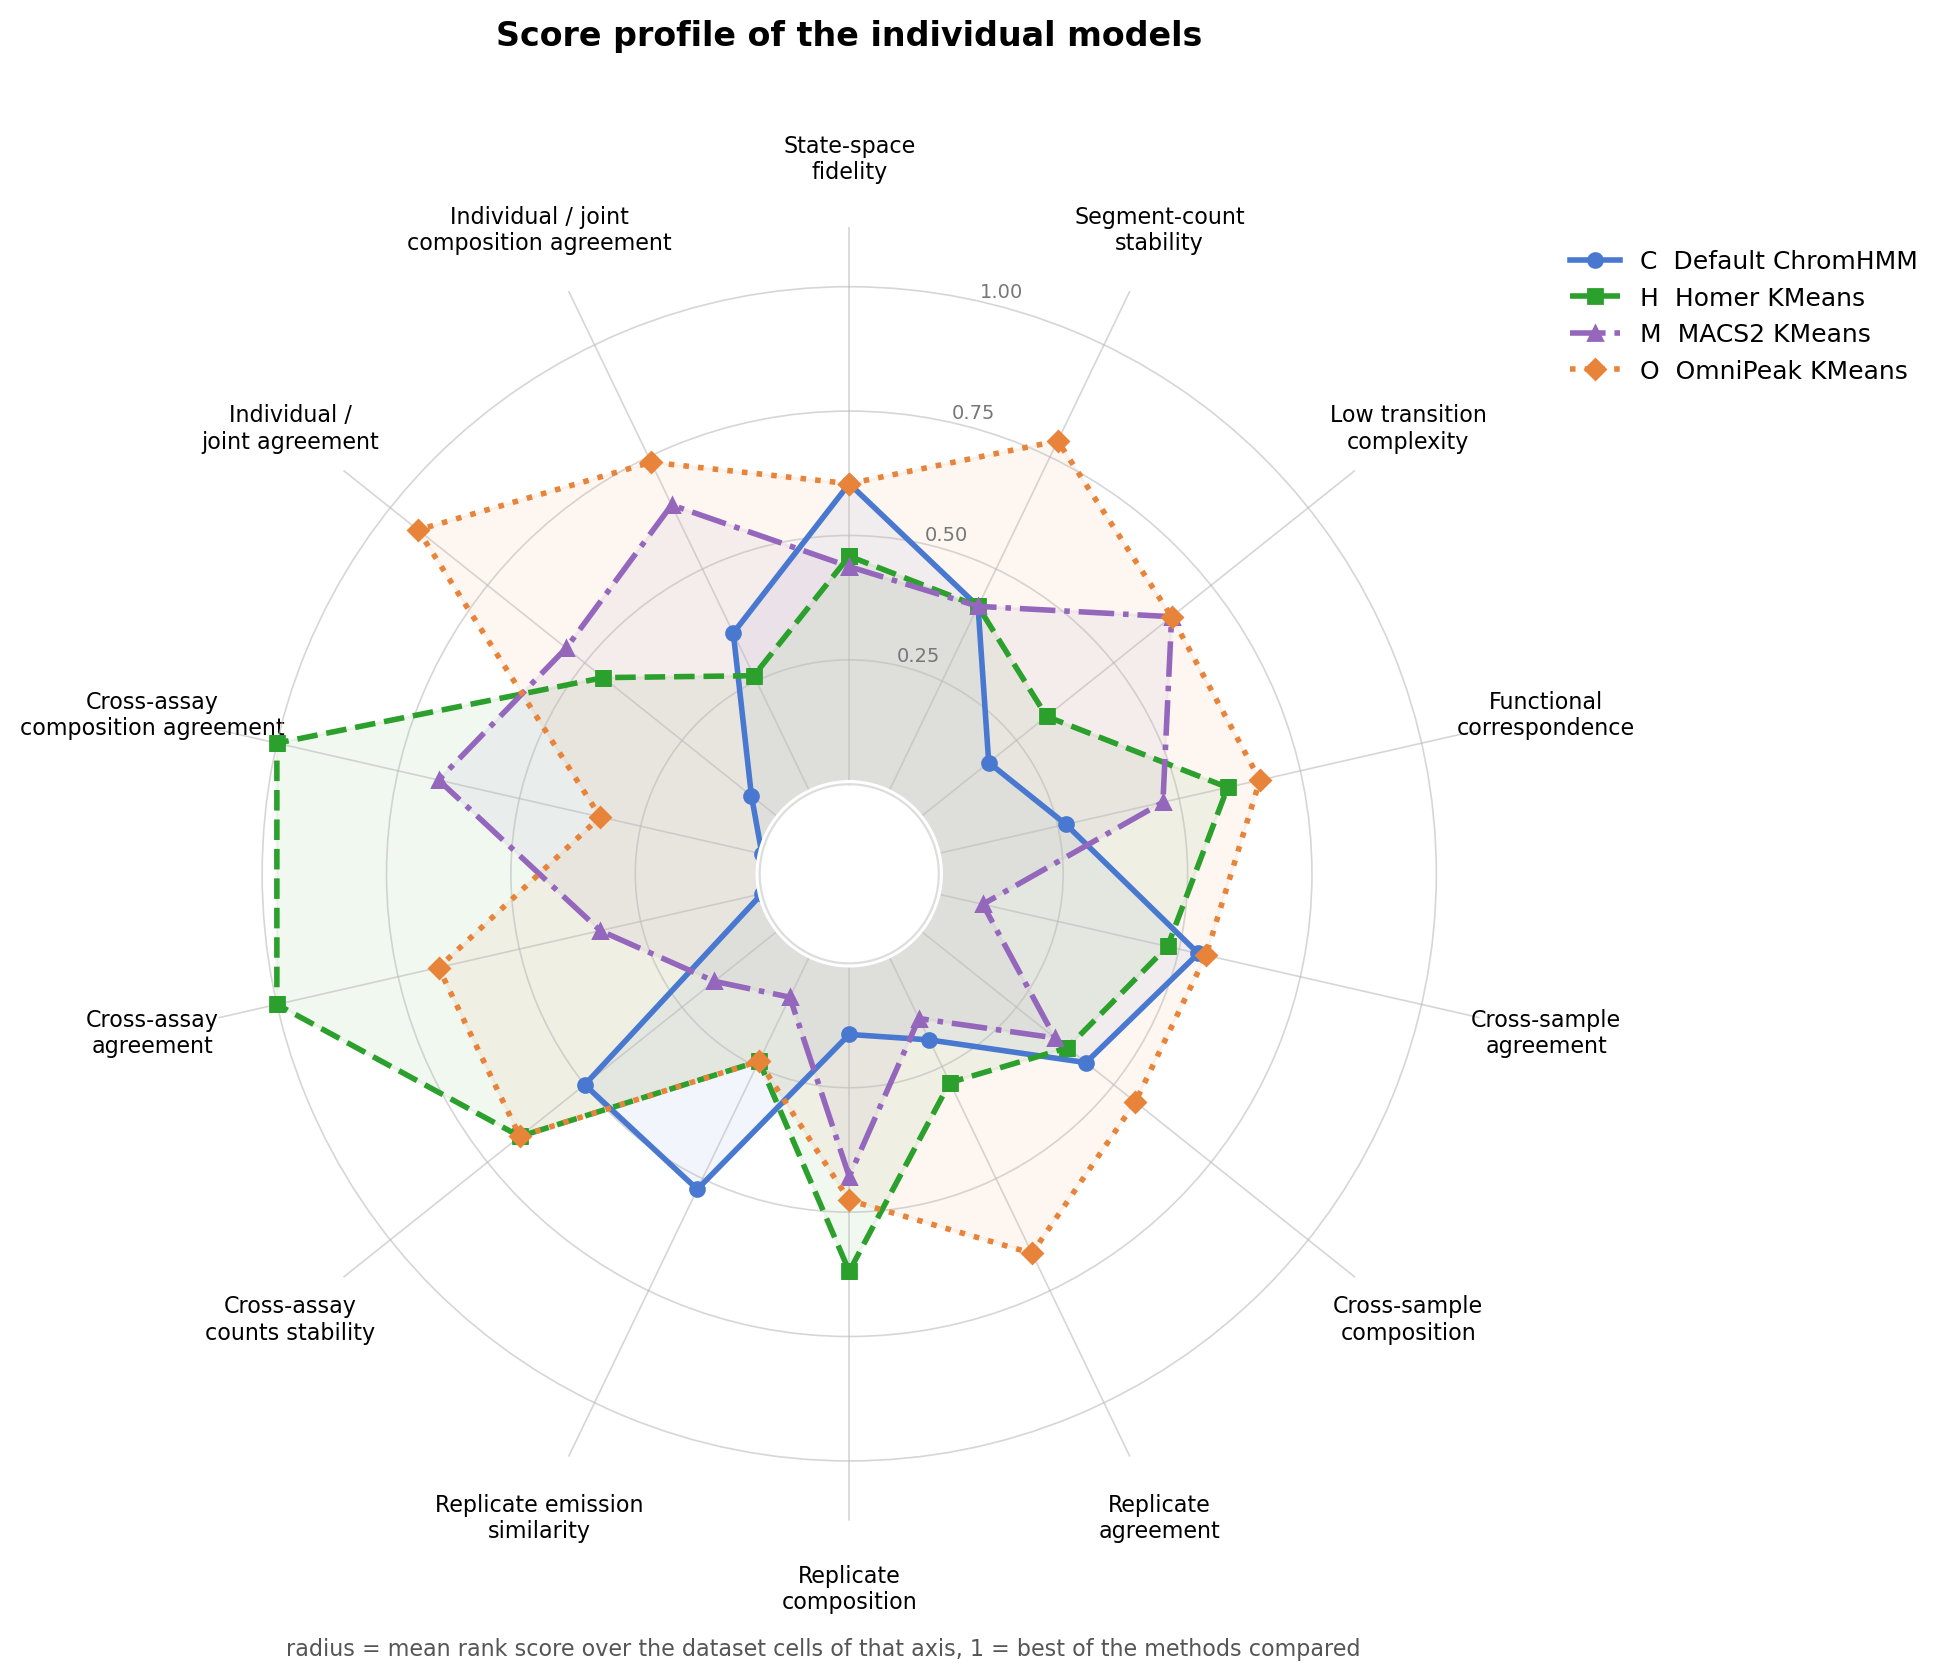

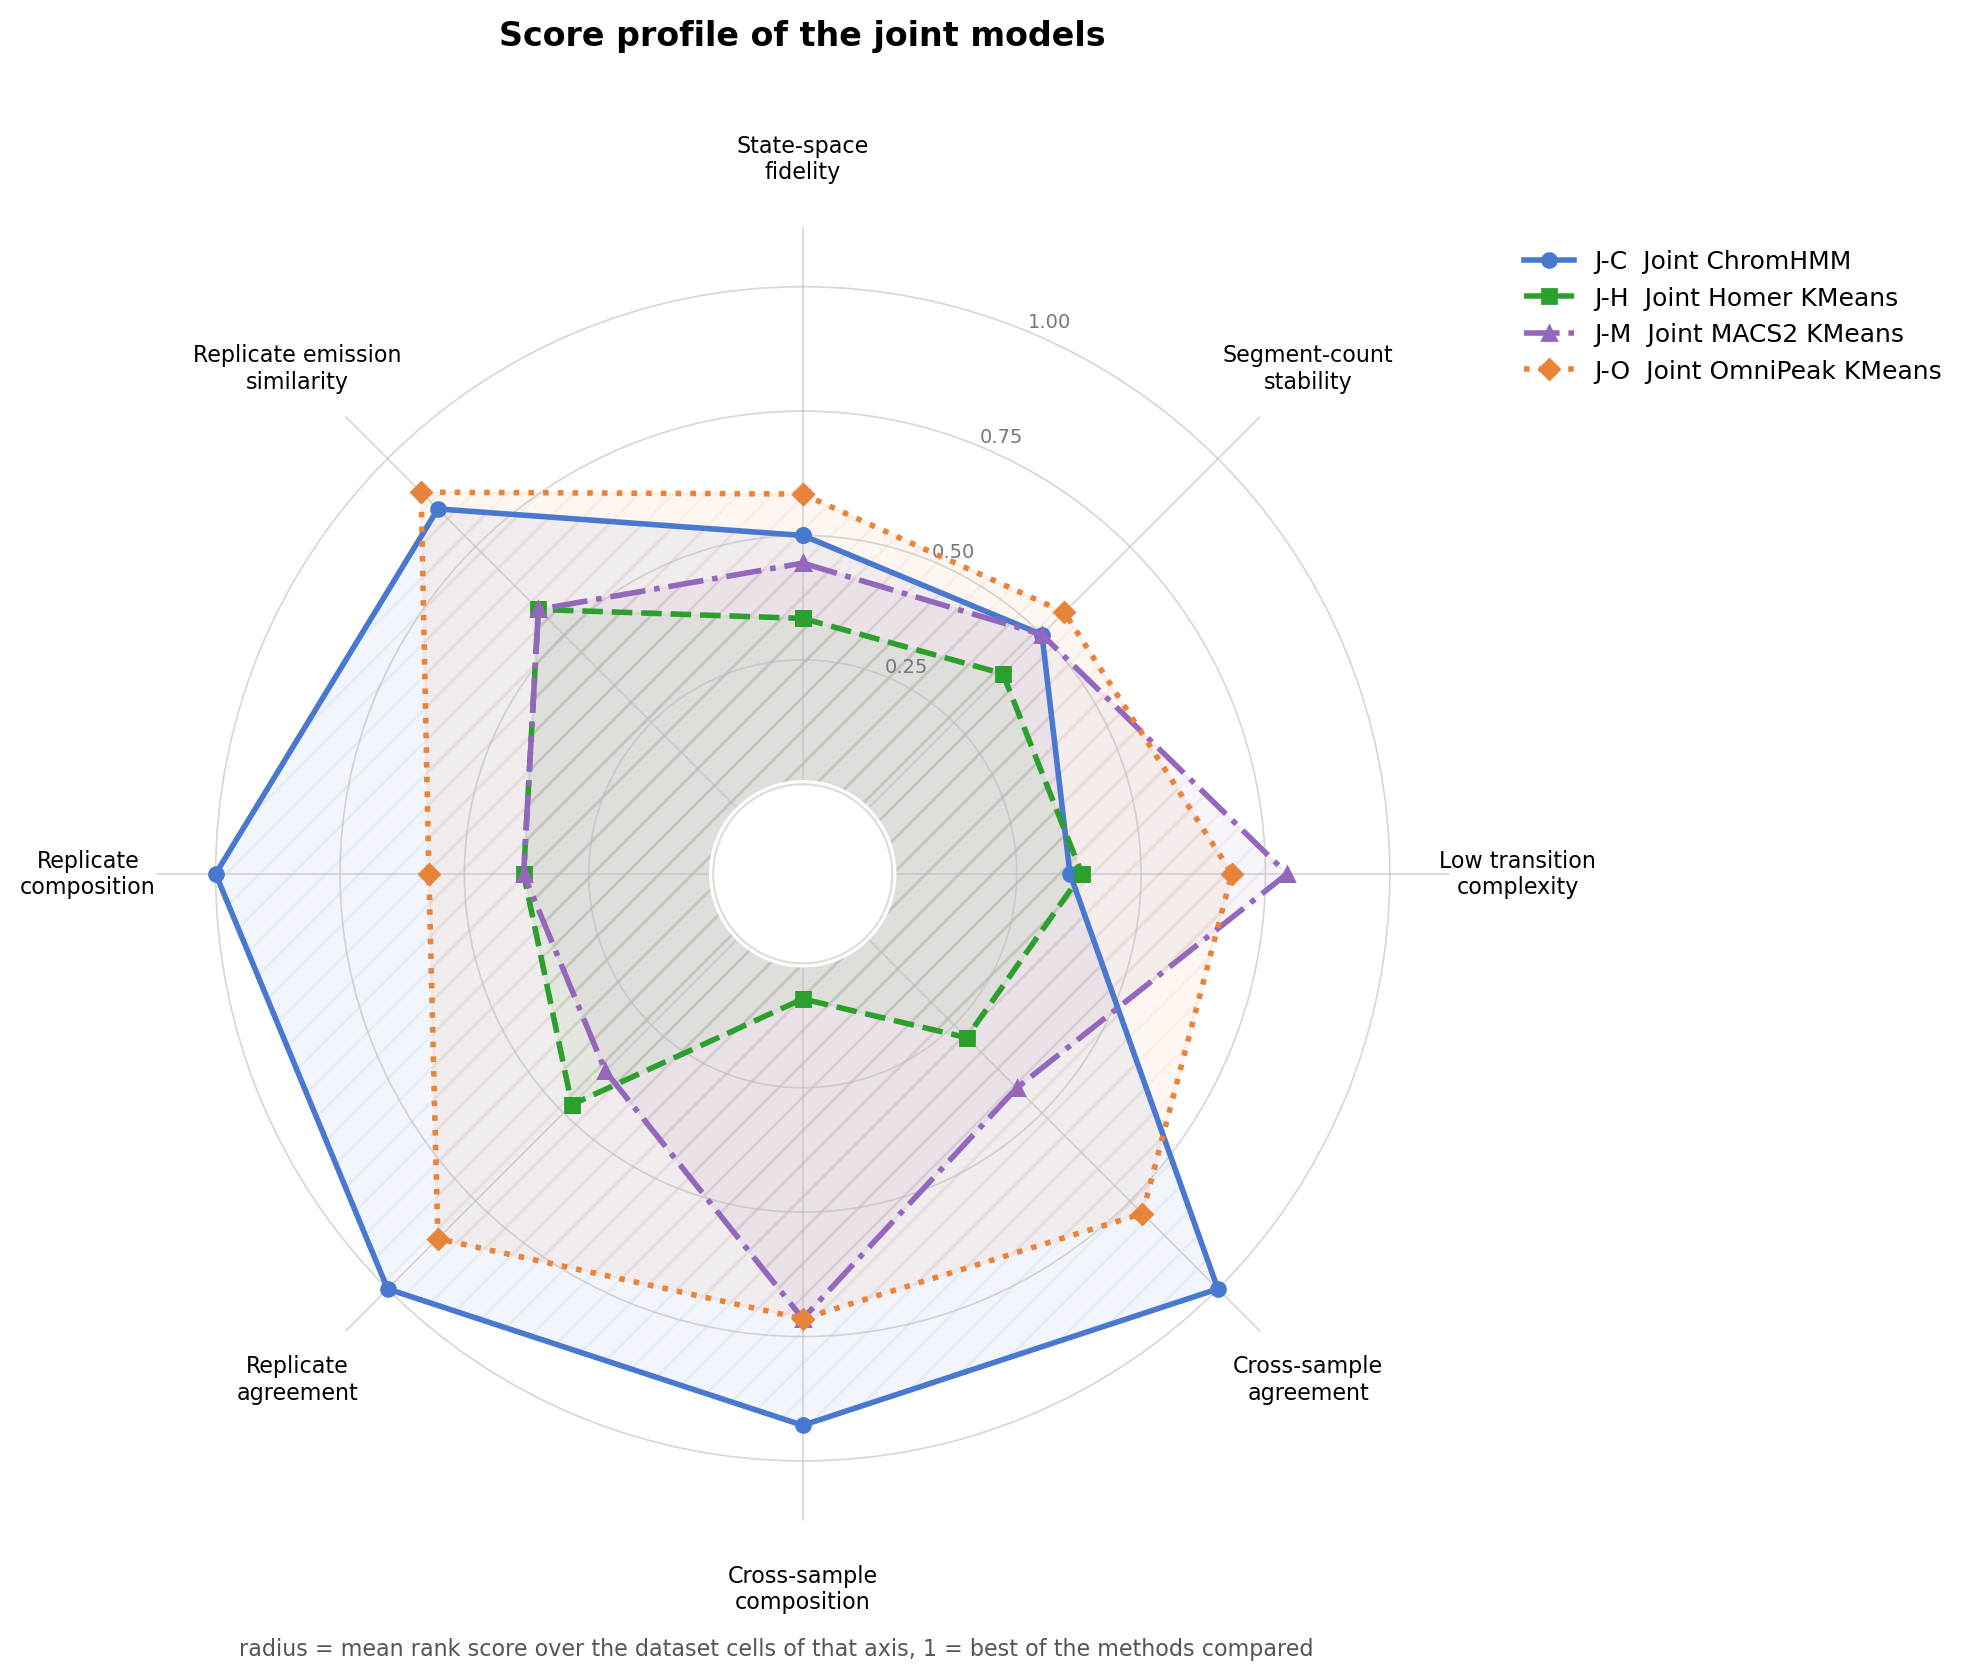

2

In [13]:
header("Score profiles")
show_all(["radar_individual.png", "radar_joint.png"],
         base=OUT, width=900)

,Rank,Method,Score,Axes,Datasets,Best axis,Worst axis
Method,,,,,,,
kmeans_omni,1,OmniPeak KMeans,0.609,14,3,Individual / joint agreement,Replicate emission similarity
kmeans_homer,2,Homer KMeans,0.513,14,3,Cross-assay agreement,Replicate emission similarity
kmeans_macs2,3,MACS2 KMeans,0.388,14,3,Cross-assay composition agreement,Cross-sample agreement
chromhmm_default,4,Default ChromHMM,0.301,14,3,State-space fidelity,Cross-assay agreement


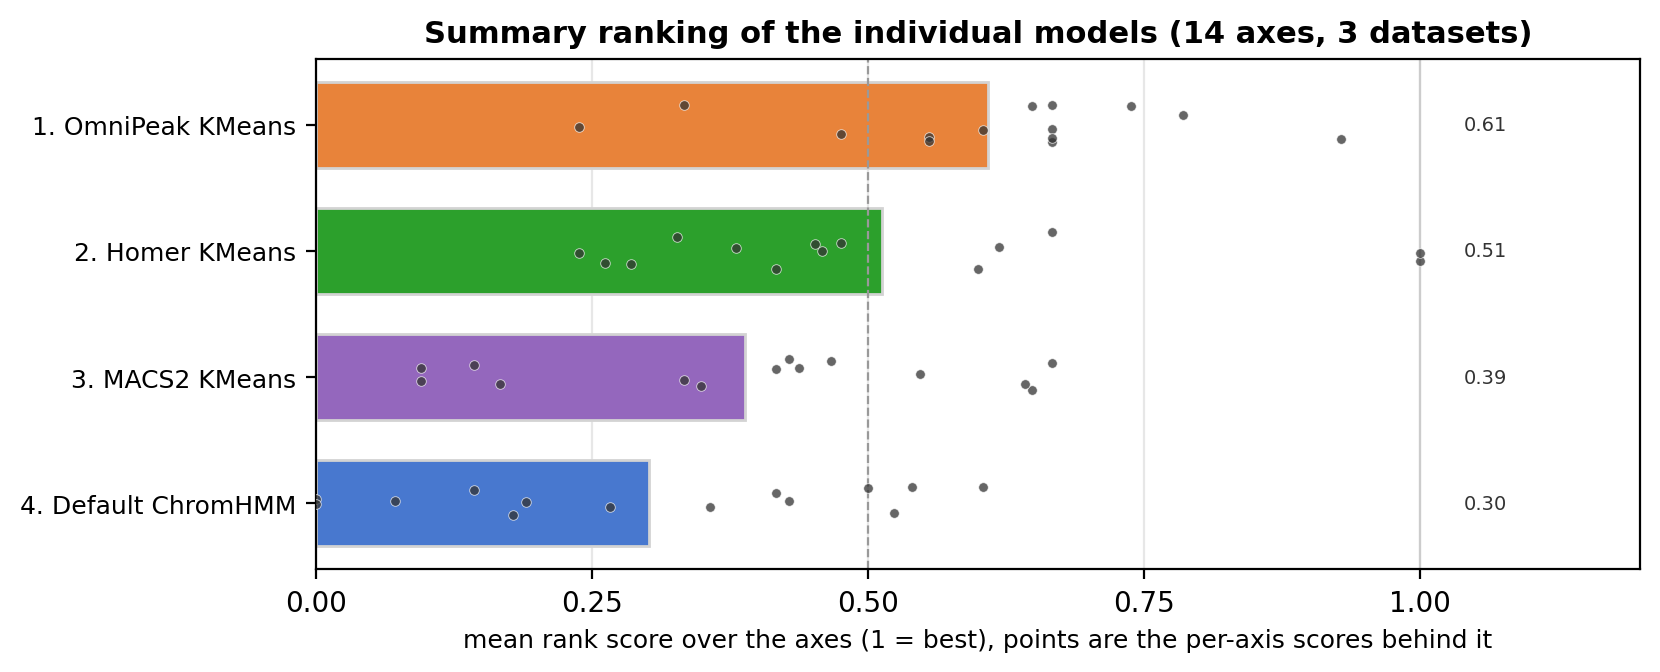

,Rank,Method,Score,Axes,Datasets,Best axis,Worst axis
Method,,,,,,,
joint_chromhmm,1,Joint ChromHMM,0.768,8,3,Cross-sample agreement,Low transition complexity
joint_kmeans_omni,2,Joint OmniPeak KMeans,0.708,8,3,Replicate emission similarity,Segment-count stability
joint_kmeans_macs2,3,Joint MACS2 KMeans,0.527,8,3,Low transition complexity,Replicate agreement
joint_kmeans_homer,4,Joint Homer KMeans,0.361,8,3,Replicate emission similarity,Cross-sample composition


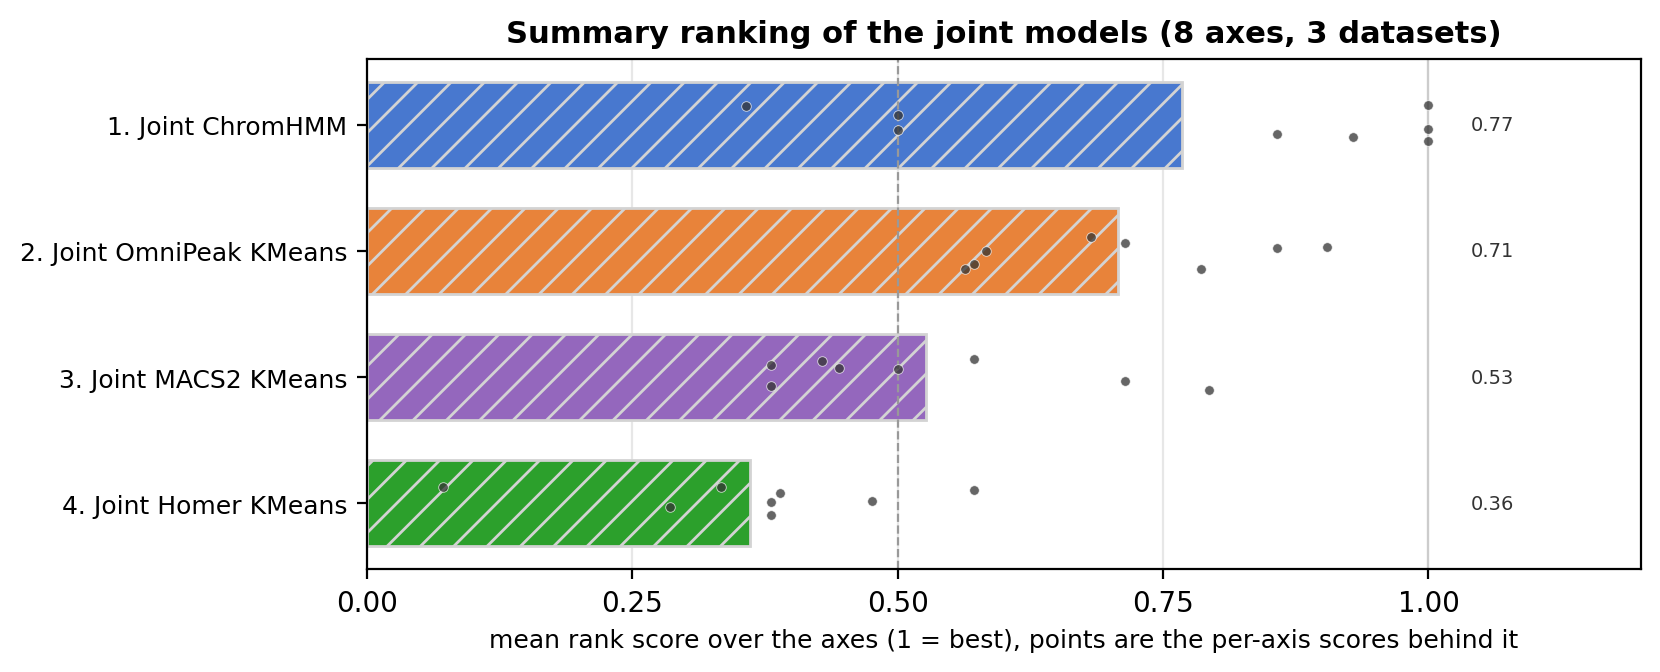

In [14]:
for group, ranking in [("individual", df_ranking_individual),
                       ("joint", df_ranking_joint)]:
    header(f"Summary ranking of the {group} models "
           f"({int(ranking['Axes'].max()) if not ranking.empty else 0} axes)")
    display(ranking.round(3))
    show_all([f"ranking_{group}.png"], base=OUT, width=820)